# **1. Perkenalan Dataset**
Sumber dataset (Kaggle): [Sumber_Dataset](https://www.kaggle.com/code/abdelruhmanessam/wine-quality)

Dataset ini terkait dengan varian merah dan putih dari wine “Vinho Verde” Portugis. Referensi [Cortez et al., 2009]. Karena masalah privasi dan logistik, hanya variabel fisikokimia (input) dan sensorik (output) yang tersedia (misalnya, tidak ada data tentang jenis anggur, merek wine, harga jual wine, dll.). Kolom targetnya adalah quality yang bertipe numerik.

Input variables (berdasarkan uji fisikokimia):
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol


Output variable (berdasarkan data sensorik):
- quality (antara 0 dan 10)

# **2. Import Library**

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# **3. Memuat Dataset**

In [76]:
df = pd.read_csv("https://drive.google.com/uc?id=1qUyOucqzTb7NGfJiBUMuDQj0rQnO9Ha2")

# **4. Exploratory Data Analysis (EDA)**

In [77]:
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [78]:
df.describe(include='all')

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,white,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,NaN,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,NaN,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,NaN,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,NaN,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,NaN,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


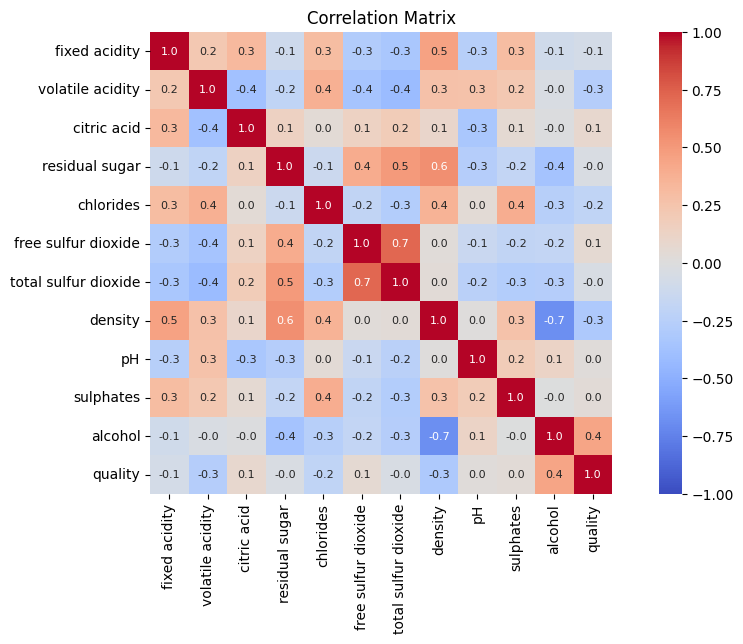

In [80]:
# Menampilkan heatmap korelasi pada kolom numerik dengan target

numeric_features = df.select_dtypes(include=['number']).columns
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
plt.figure(figsize=(12, 6))
correlation_matrix = df[numeric_features].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=True, square=True, fmt='.1f', annot_kws={'size':8})
plt.title('Correlation Matrix')
plt.show()

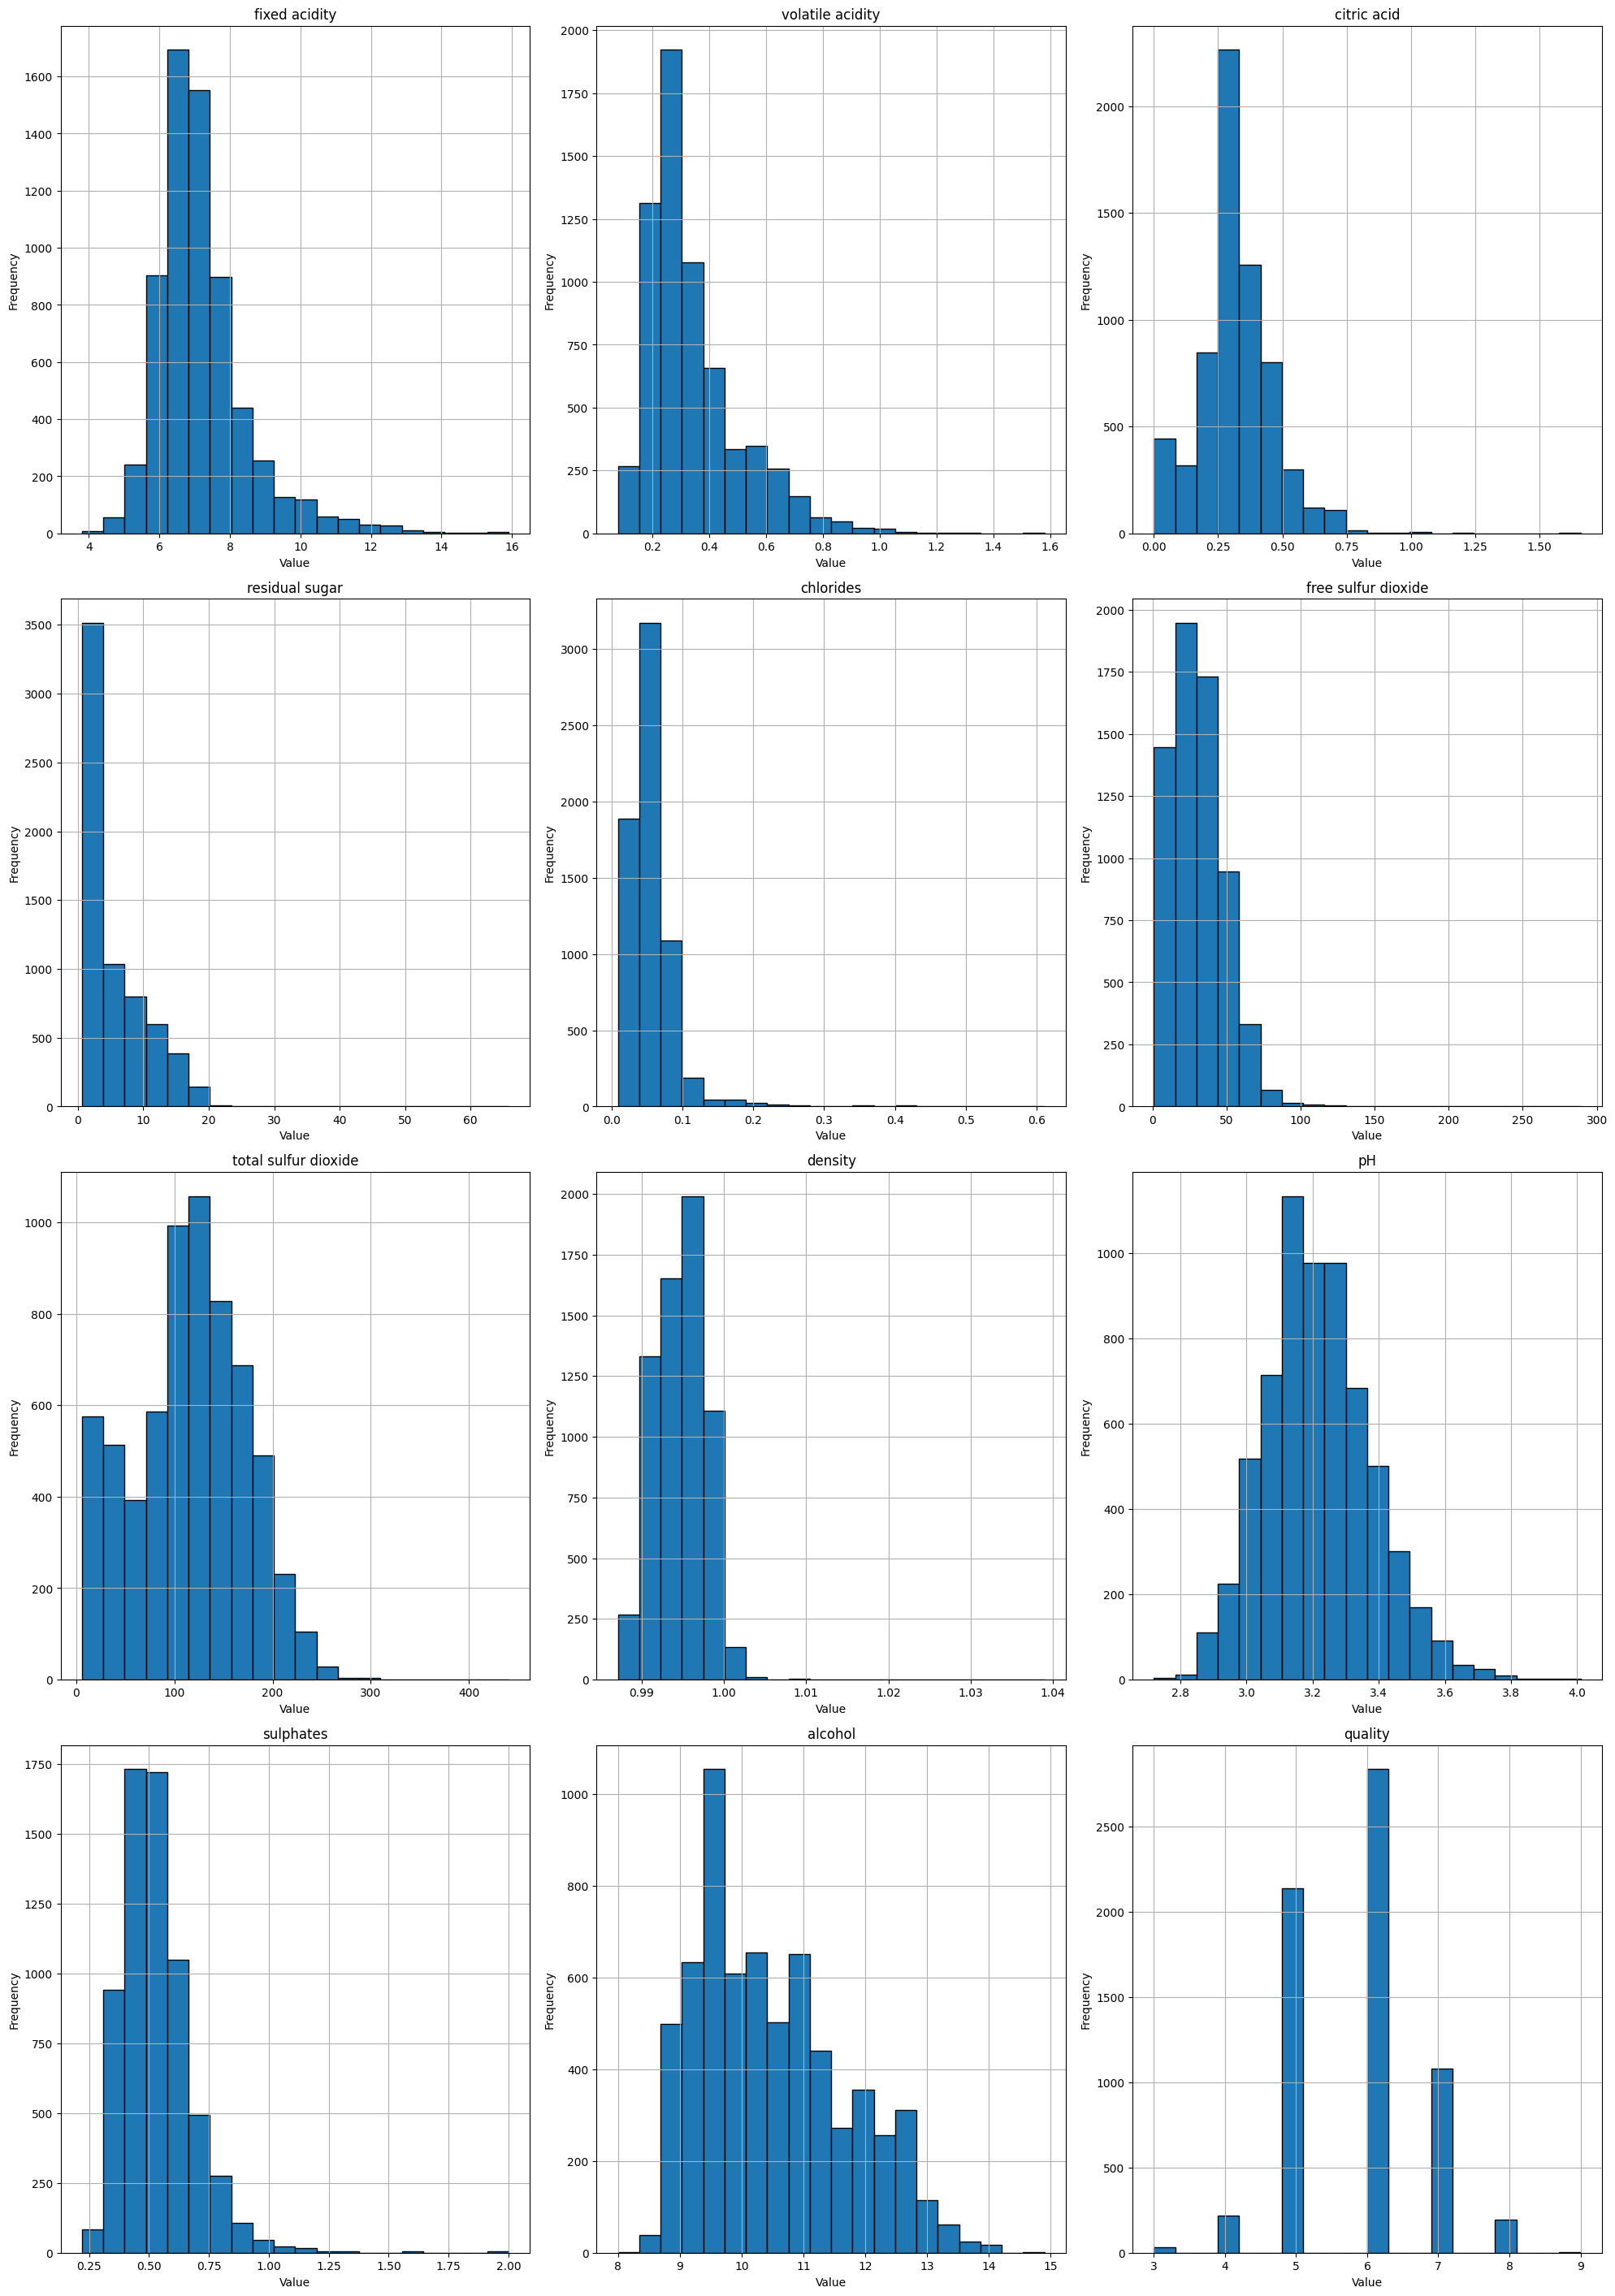

In [81]:
# Menampilkan histogram untuk semua kolom numerik

num_vars = df.shape[1]

n_cols = 3
n_rows = -(-num_vars // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 7))
axes = axes.flatten()

for i, column in enumerate(numeric_features):
    df[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15284\1899210689.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='type', data=df, palette=['blue', 'orange'])


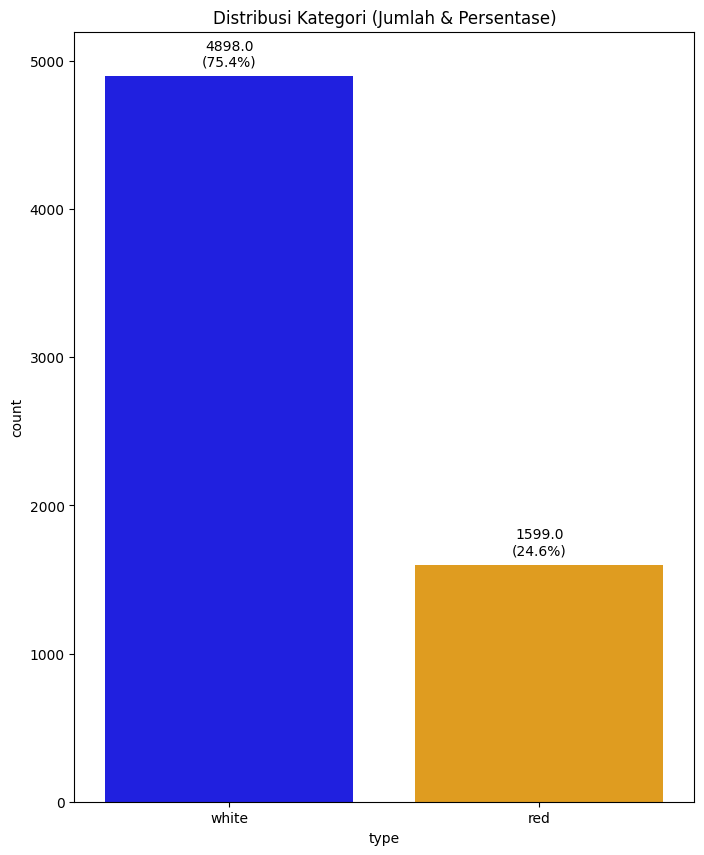

In [82]:
# Menampilkan histogram perbandingan kelas pada kolom kategorikal
plt.figure(figsize=(8, 10))
ax = sns.countplot(x='type', data=df, palette=['blue', 'orange'])

total = df.shape[0]

# Tambahkan label (jumlah & persentase) di atas hist
for container in ax.containers:
    # Membuat label
    labels = [f'{h}\n({h/total*100:.1f}%)' for h in container.datavalues]
    
    # Menempelkan label
    ax.bar_label(container, labels=labels, label_type='edge', padding=5)

# Merapikan judul dan label
plt.title('Distribusi Kategori (Jumlah & Persentase)')
plt.ylim(0, total * 0.8) # Memberi ruang kosong di atas agar tulisan tidak terpotong
plt.show()

# **5. Data Preprocessing**

In [83]:
df.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

Karena tidak ada data yang hilang, maka kode berikutnya tidak dipakai pada file ini.

In [84]:
missing_values = df[df.isna().any(axis=1)].index
len(missing_values)

34

karena total missing_values hanya 34/6900 data atau 0.5%, maka missing values pada kasus ini dihapus.

In [85]:
# Menangani data yang hilang 
df = df.drop(missing_values)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6463 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6463 non-null   object 
 1   fixed acidity         6463 non-null   float64
 2   volatile acidity      6463 non-null   float64
 3   citric acid           6463 non-null   float64
 4   residual sugar        6463 non-null   float64
 5   chlorides             6463 non-null   float64
 6   free sulfur dioxide   6463 non-null   float64
 7   total sulfur dioxide  6463 non-null   float64
 8   density               6463 non-null   float64
 9   pH                    6463 non-null   float64
 10  sulphates             6463 non-null   float64
 11  alcohol               6463 non-null   float64
 12  quality               6463 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 706.9+ KB


In [86]:
# Melihat baris yang duplikat saja
df.duplicated().sum()

np.int64(1168)

Data yang terduplikasi berjumlah 20% dari keseluruhan dataset. Meskipun begitu, tetap dihapus karena dapat menyebabkan overfitting saat pembelajaran model

In [87]:
# Menghapus data duplikat menggunakan drop_duplicates().
df = df.drop_duplicates()
df.shape

(5295, 13)

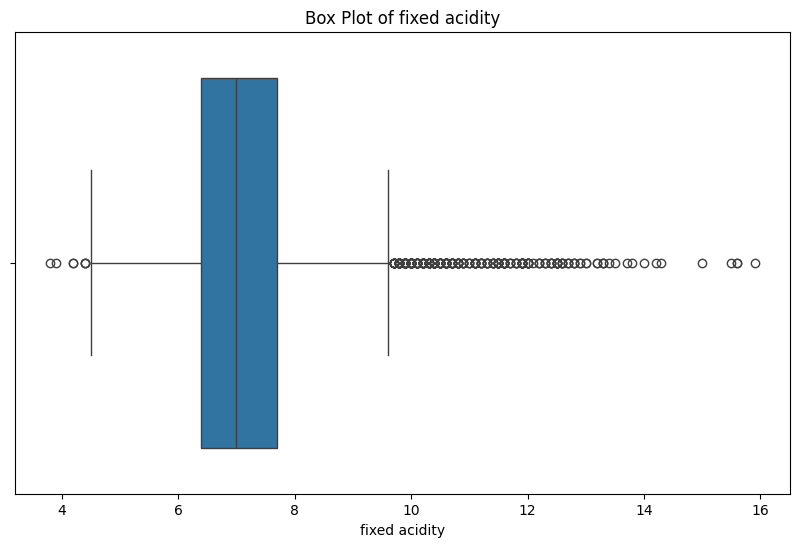

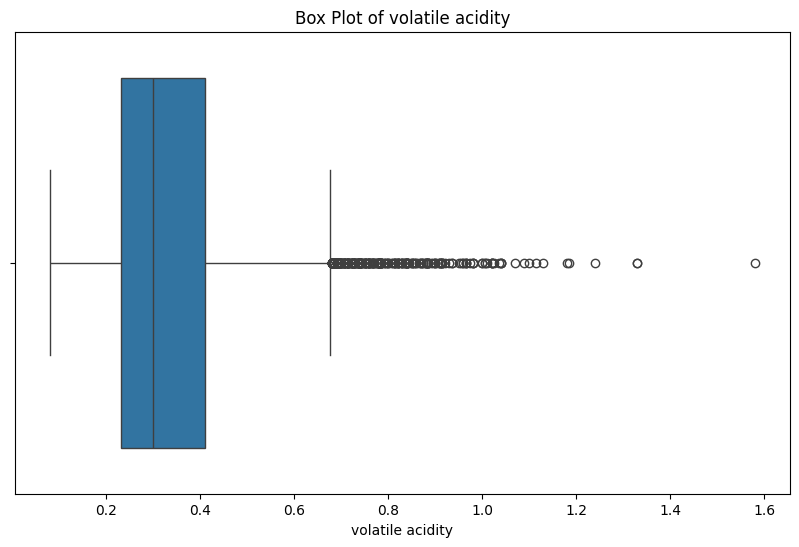

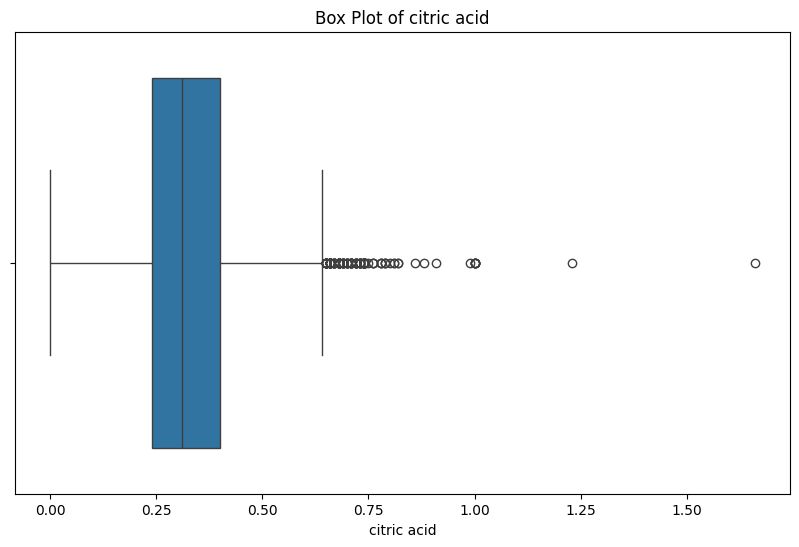

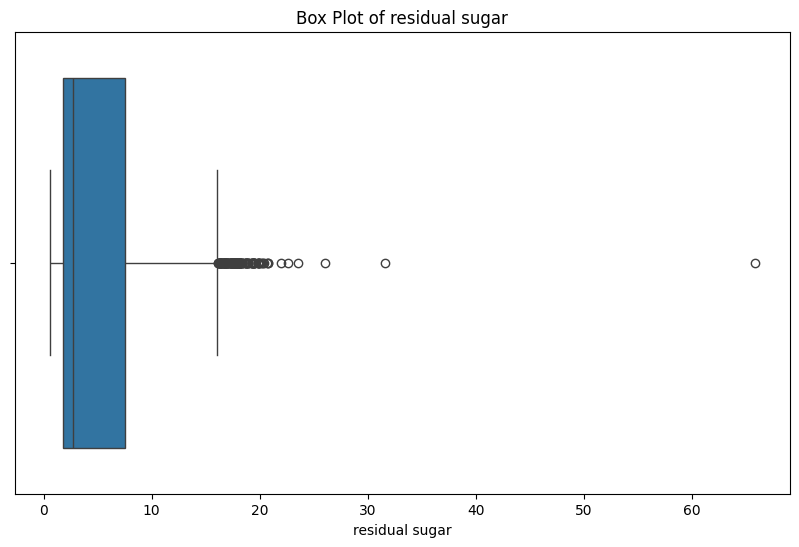

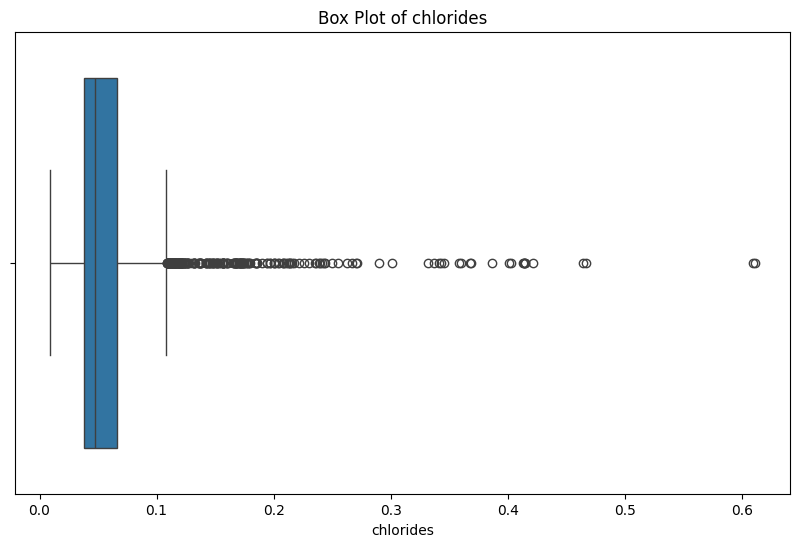

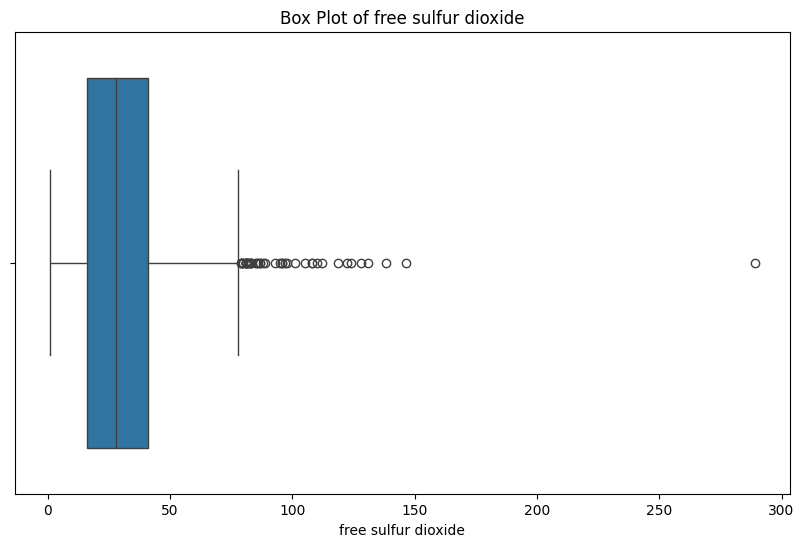

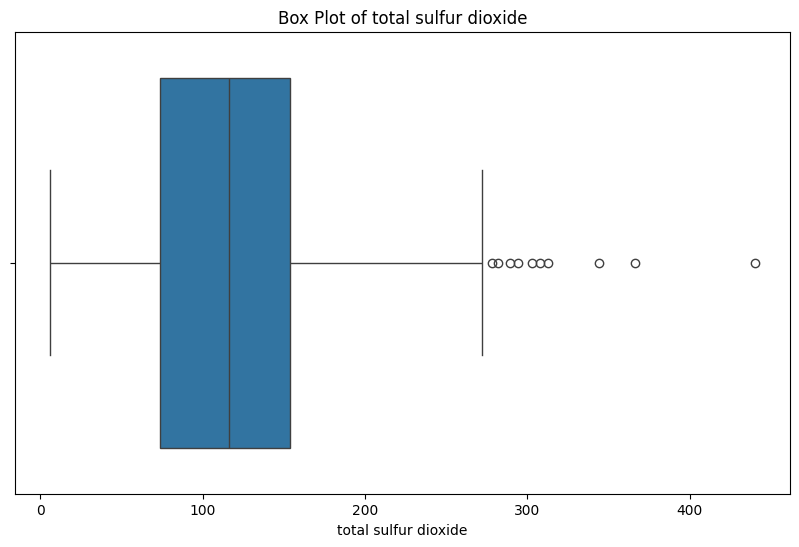

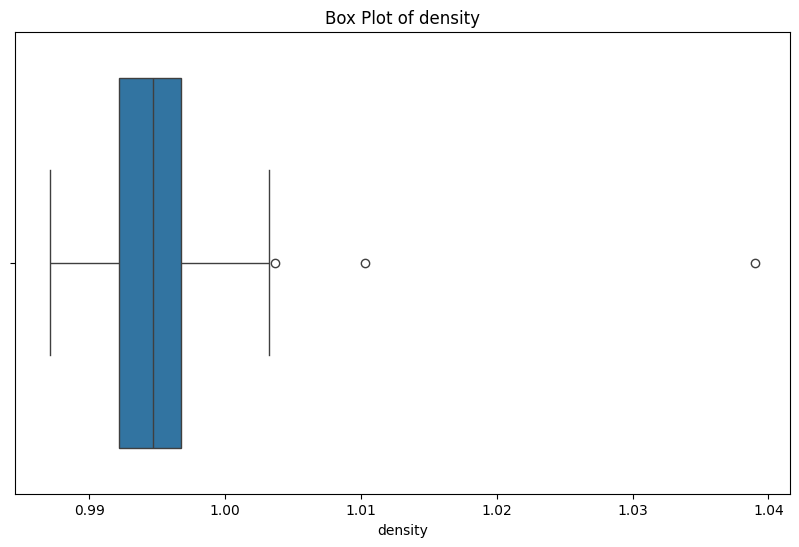

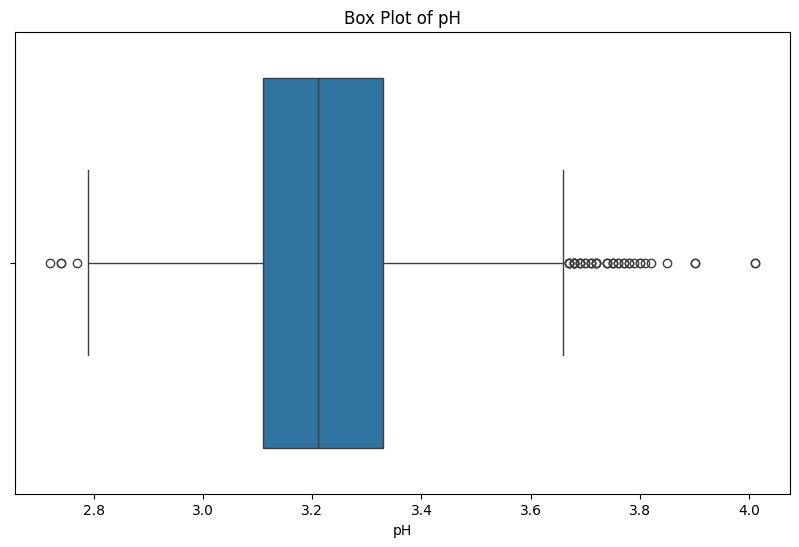

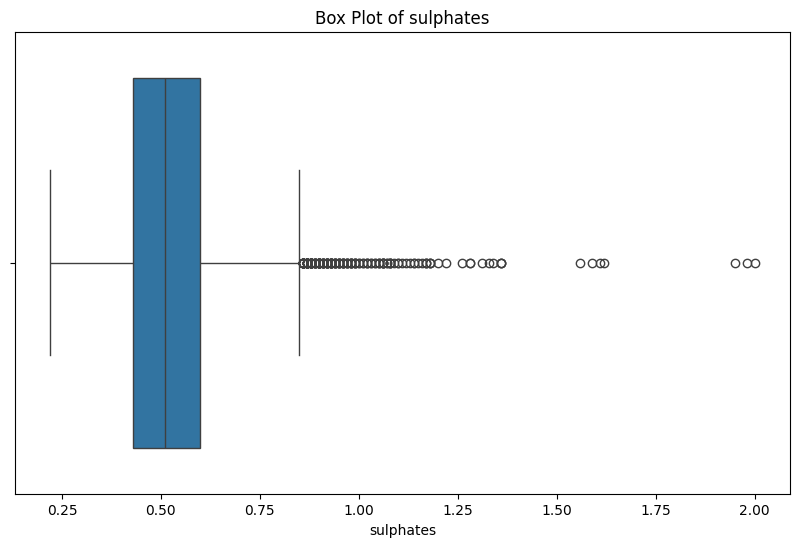

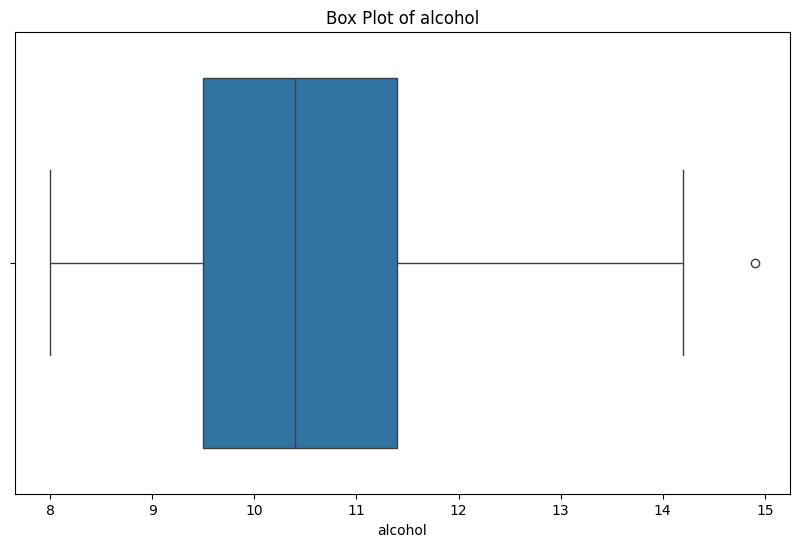

In [88]:
# Visualisasi bar chart untuk identifikasi outliers

numeric_features = df.drop(columns=['quality']).select_dtypes(include=['number']).columns
for feature in numeric_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

In [89]:
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1
# Menghitung persentase outlier per kolom
outlier_mask = (
    (df[numeric_features] < (Q1 - 1.5 * IQR)) |
    (df[numeric_features] > (Q3 + 1.5 * IQR))
)
outlier_ratio = outlier_mask.mean()
high_outlier_columns = outlier_ratio[outlier_ratio > 0.5].index.tolist()
summary = pd.DataFrame({
    "outlier_ratio": outlier_ratio,
    "outlier_percentage": outlier_ratio * 100
}).sort_values("outlier_ratio", ascending=False)

summary

,outlier_ratio,outlier_percentage
fixed acidity,0.057224,5.722380
volatile acidity,0.052502,5.250236
chlorides,0.044381,4.438149
sulphates,0.030784,3.078376
citric acid,0.027007,2.700661
residual sugar,0.026440,2.644004
pH,0.009254,0.925401
free sulfur dioxide,0.008310,0.830973
total sulfur dioxide,0.001889,0.188857
density,0.000567,0.056657


Pada dataset ini, data yang memiliki outliers < 25% dari keseluruhan dataset, sehingga outliers tidak dihapus

In [90]:
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

In [91]:
# Melakukan feature encoding untuk fitur kategorikal.
label_encoder = LabelEncoder()
df['type'] = label_encoder.fit_transform(df['type'])


In [92]:
df.to_csv("wine_quality_preprocessing.csv", index=False)